<a href="https://colab.research.google.com/github/vlastami/UniversityMaterials/blob/master/windkessel_4wk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4-prvkový Windkesselův model (4WK)

Implementace na základě:
> Gerringer et al. (2018). *Lumped-parameter models of the pulmonary vasculature during the progression of pulmonary arterial hypertension.* Physiological Reports, 6(3), e13586.

## Popis modelu

4-prvkový Windkesselův model popisuje vztah mezi průtokem krve $Q(t)$ a arteriálním tlakem $P(t)$ pomocí následující ODE (rovnice 1 z článku):

$$\frac{dP}{dt} + \frac{1}{R_d C} P = L\frac{d^2Q}{dt^2} + \left(R + \frac{L}{R_d C}\right)\frac{dQ}{dt} + \left(\frac{1}{C} + \frac{R}{R_d C}\right)Q$$

**Parametry modelu (normotenzní skupina PL, Tabulka 2):**

| Parametr | Hodnota | Popis |
|----------|---------|-------|
| $R_d$ | 0,57 mmHg·min/mL | Distální (periferní) odpor |
| $R$ | 0,05 mmHg·min/mL | Proximální (charakteristický) odpor |
| $C$ | 0,44 mL/mmHg | Celková arteriální poddajnost |
| $L$ | 2,6×10⁻⁵ mmHg·min²/mL | Indukčnost (setrvačnost krve) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

## 1. Parametry modelu

Hodnoty z Tabulky 2, normotenzní skupina (PL).  
Všechny veličiny jsou v jednotkách mmHg, mL a minuty (shodně s článkem).


In [2]:
# --- Parametry modelu (normotenzní skupina PL, Tabulka 2) ---
Rd = 0.57    # mmHg·min/mL  — distální odpor
R  = 0.05    # mmHg·min/mL  — proximální odpor
C  = 0.44    # mL/mmHg      — poddajnost
L  = 0.26e-4 # mmHg·min²/mL — indukčnost (L × 10⁻⁴ dle Tabulky 2)

# Srdeční frekvence a délka simulace
HR      = 300           # tepů/min — srdeční frekvence potkana (~300–400 tpm)
T_cycle = 1.0 / HR      # délka jednoho srdečního cyklu [min] = 1/300 min ≈ 200 ms
T_total = 10.0 / 60.0   # délka simulace: 10 sekund [min]
n_cycles = round(T_total / T_cycle)

print(f"Srdeční frekvence: {HR} tpm")
print(f"Délka cyklu:       {T_cycle*60*1000:.1f} ms")
print(f"Délka simulace:    {T_total*60:.1f} s")
print(f"Počet cyklů:       {n_cycles}")


Srdeční frekvence: 300 tpm
Délka cyklu:       200.0 ms
Délka simulace:    10.0 s
Počet cyklů:       50


## 2. Syntetický průtokový signál Q(t)

Rekonstruujeme fyziologicky věrohodný průtokový signál hlavní plicní tepny (Obr. 1B, střední panel z článku). Signál má:
- ostrý systolický vrchol (~140 mL/min pro normotenzního potkana),
- přibližně nulový diastolický průtok,
- malý zpětný průtok v oblasti dikrotického zářezu.


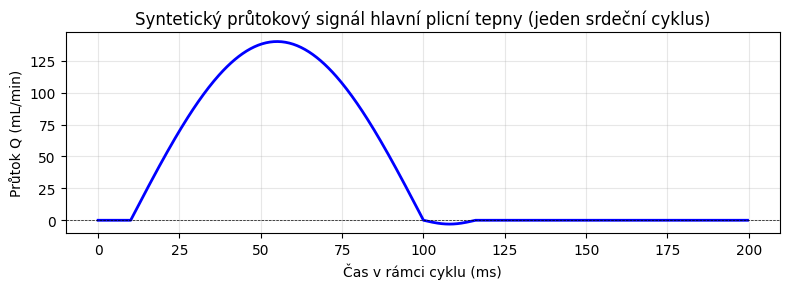

Průměrný průtok: 40.0 mL/min
Vrcholový průtok: 140.0 mL/min


In [3]:
def make_flow_waveform(t_cycle):
    """
    Syntetický průtokový signál hlavní plicní tepny pro jeden srdeční cyklus.
    Tvar odpovídá Obr. 1B (střední panel) z Gerringer et al. 2018.

    Systolická fáze je aproximována půlsinusovým pulsem:
    - průměrný průtok ~40 mL/min
    - systola trvá ~45 % cyklu (odpovídá potkanu při HR ~300 tpm)
    - malý zpětný průtok po uzávěru chlopně
    """
    n_pts = 500
    tau = np.linspace(0, 1, n_pts, endpoint=False)

    t_sys_start = 0.05
    t_sys_end   = 0.50
    Q_peak      = 140.0  # mL/min
    Q_backflow  = -3.0   # mL/min

    Q = np.zeros(n_pts)
    sys_mask = (tau >= t_sys_start) & (tau <= t_sys_end)
    tau_sys_norm = (tau[sys_mask] - t_sys_start) / (t_sys_end - t_sys_start)
    Q[sys_mask] = Q_peak * np.sin(np.pi * tau_sys_norm)

    t_back_end = t_sys_end + 0.08
    back_mask = (tau >= t_sys_end) & (tau <= t_back_end)
    tau_back_norm = (tau[back_mask] - t_sys_end) / 0.08
    Q[back_mask] = Q_backflow * np.sin(np.pi * tau_back_norm)

    return tau * t_cycle, Q


# Šablona průtoku a kubický splin — sestaví se JEDNOU, sdílí se napříč všemi funkcemi
Qt_template, QQ_template = make_flow_waveform(T_cycle)
cs_flow = CubicSpline(Qt_template, QQ_template, bc_type='periodic')


def Q_func(t_min, t_cycle, *args):
    """Průtok Q(t) — interpolace předpočítaným splinem."""
    return float(cs_flow(t_min % t_cycle))


def dQ_func(t_min, t_cycle, *args):
    """První derivace dQ/dt."""
    return float(cs_flow(t_min % t_cycle, 1))


def d2Q_func(t_min, t_cycle, *args):
    """Druhá derivace d²Q/dt²."""
    return float(cs_flow(t_min % t_cycle, 2))


fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(Qt_template * 1000 * 60, QQ_template, 'b-', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('Čas v rámci cyklu (ms)')
ax.set_ylabel('Průtok Q (mL/min)')
ax.set_title('Syntetický průtokový signál hlavní plicní tepny (jeden srdeční cyklus)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Průměrný průtok: {np.mean(QQ_template):.1f} mL/min")
print(f"Vrcholový průtok: {np.max(QQ_template):.1f} mL/min")


## 3. Formulace ODE

Rovnice 4WK modelu (Rov. 1 z článku) je **diferenciální rovnice 1. řádu** v $P$:

$$\frac{dP}{dt} + \frac{1}{R_d C} P = L\frac{d^2Q}{dt^2} + \left(R + \frac{L}{R_d C}\right)\frac{dQ}{dt} + \left(\frac{1}{C} + \frac{R}{R_d C}\right)Q$$

Upravená pro přímou integraci:

$$\frac{dP}{dt} = -\frac{P}{R_d C} + L\frac{d^2Q}{dt^2} + \left(R + \frac{L}{R_d C}\right)\frac{dQ}{dt} + \left(\frac{1}{C} + \frac{R}{R_d C}\right)Q$$

In [4]:
def windkessel_4wk(t, y, Rd, R, C, L, t_cycle, Qt_templ, QQ_templ):
    """
    ODE 4-prvkového Windkesselova modelu (Rov. 1 z Gerringer et al. 2018).

    dP/dt = -P/(Rd*C) + L*d2Q/dt2 + (R + L/(Rd*C))*dQ/dt + (1/C + R/(Rd*C))*Q

    Stavový vektor: y = [P]
    """
    P = y[0]
    tc = t % t_cycle
    # cs_flow je předpočítán v buňce 2 — žádná nová alokace při každém volání
    dPdt = ( -P / (Rd * C)
             + L * float(cs_flow(tc, 2))
             + (R + L / (Rd * C)) * float(cs_flow(tc, 1))
             + (1.0/C + R / (Rd * C)) * float(cs_flow(tc)) )
    return [dPdt]


# ── Počáteční podmínka P0: Fourierova analýza ustáleného stavu ────────────
# Pro lineární ODE je steady-state analyticky řešitelný bez numerického warmupu.
# Rozložíme pravou stranu f(t) do Fourierovy řady; pro každou harmonickou složku k:
#   P_k = F_k / (1/(Rd·C) + i·k·ω)
omega  = 2 * np.pi / T_cycle
dQ_ss  = cs_flow(Qt_template, 1)
d2Q_ss = cs_flow(Qt_template, 2)

f_t = ( L * d2Q_ss
        + (R + L / (Rd * C)) * dQ_ss
        + (1.0/C + R / (Rd * C)) * QQ_template )

N    = len(f_t)
F_k  = np.fft.rfft(f_t) / N
P_k  = np.array([F_k[k] / (1/(Rd*C) + 1j*k*omega) for k in range(len(F_k))])
P_ss = np.fft.irfft(P_k * N, n=N)
P0   = P_ss[0]

print(f"Ustálený střední tlak (Fourier): {np.mean(P_ss):.2f} mmHg")
print(f"Počáteční podmínka P0 = {P0:.2f} mmHg")

# ── Simulace ──────────────────────────────────────────────────────────────
t_span = (0.0, T_total)
t_eval = np.linspace(0.0, T_total, 5000)
solver_args = (Rd, R, C, L, T_cycle, Qt_template, QQ_template)

sol = solve_ivp(
    fun=windkessel_4wk,
    t_span=t_span,
    y0=[P0],
    t_eval=t_eval,
    method='RK45', rtol=1e-8, atol=1e-10,
    args=solver_args
)
print(f"Stav solveru: {sol.message}")


Ustálený střední tlak (Fourier): 24.77 mmHg
Počáteční podmínka P0 = 22.61 mmHg
Stav solveru: The solver successfully reached the end of the integration interval.


## 4. Výsledky

In [5]:
# Převod času zpět na sekundy
t_sec = sol.t * 60.0
P_sol = sol.y[0]

# Rekonstrukce Q(t) pro celou délku simulace
Q_full = np.array([Q_func(tt, T_cycle, Qt_template, QQ_template) for tt in sol.t])

P_sys  = np.max(P_sol)
P_dia  = np.min(P_sol)
P_mean = np.mean(P_sol)

print("=" * 50)
print("  Simulované hemodynamické parametry")
print("=" * 50)
print(f"  Systolický tlak:   {P_sys:.1f}  mmHg")
print(f"  Diastolický tlak:  {P_dia:.1f}  mmHg")
print(f"  Střední tlak:      {P_mean:.1f}  mmHg")
print(f"  Pulzní tlak:       {P_sys-P_dia:.1f}  mmHg")
print()
print("  Reference (Tabulka 2, skupina PL):")
print("  Systolický ~33,6 mmHg,  střední tlak ~24,1 mmHg")


  Simulované hemodynamické parametry
  Systolický tlak:   33.0  mmHg
  Diastolický tlak:  14.0  mmHg
  Střední tlak:      24.7  mmHg
  Pulzní tlak:       19.0  mmHg

  Reference (Tabulka 2, skupina PL):
  Systolický ~33,6 mmHg,  střední tlak ~24,1 mmHg


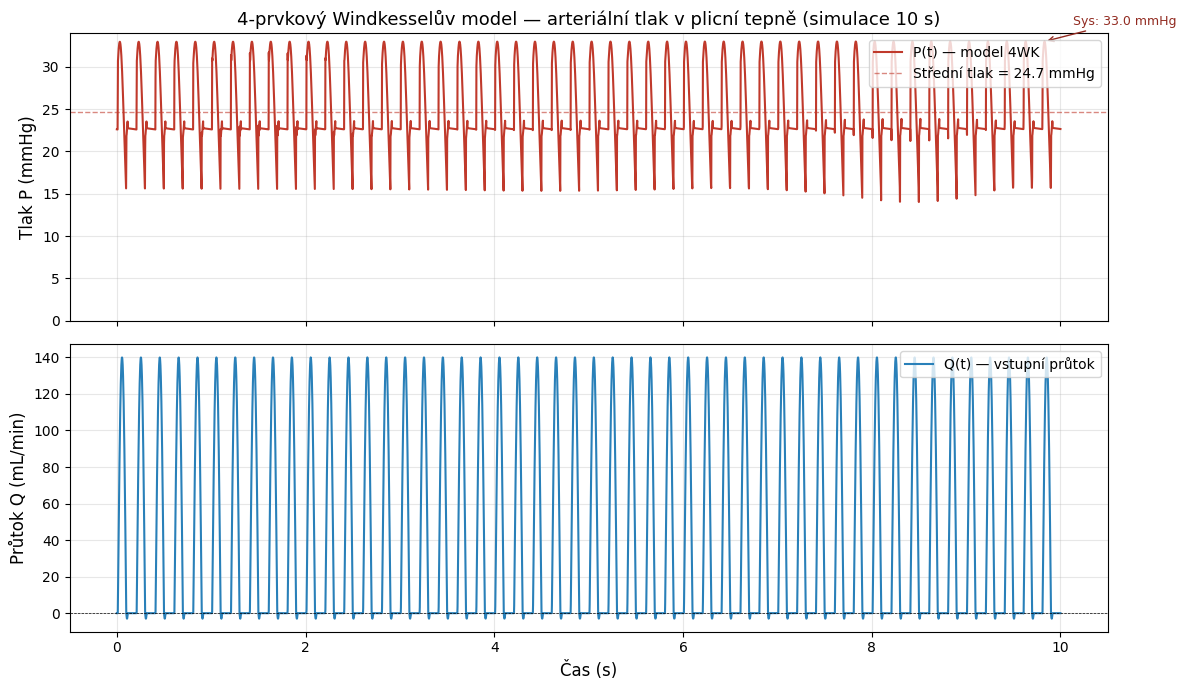

In [6]:
# ── Hlavní obrázek: tlak + průtok po dobu 10 sekund ───────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Horní panel: arteriální tlak
ax1 = axes[0]
ax1.plot(t_sec, P_sol, color='#C0392B', linewidth=1.5, label='P(t) — model 4WK')
ax1.axhline(P_mean, color='#C0392B', linewidth=1, linestyle='--', alpha=0.6,
            label=f'Střední tlak = {P_mean:.1f} mmHg')
ax1.set_ylabel('Tlak P (mmHg)', fontsize=12)
ax1.set_title('4-prvkový Windkesselův model — arteriální tlak v plicní tepně (simulace 10 s)', fontsize=13)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Anotace systolického maxima (první cyklus)
ax1.annotate(f'Sys: {P_sys:.1f} mmHg', xy=(t_sec[np.argmax(P_sol)], P_sys),
             xytext=(t_sec[np.argmax(P_sol)] + 0.3, P_sys + 2),
             fontsize=9, color='#922B21',
             arrowprops=dict(arrowstyle='->', color='#922B21', lw=1))

# Dolní panel: průtok
ax2 = axes[1]
ax2.plot(t_sec, Q_full, color='#2980B9', linewidth=1.5, label='Q(t) — vstupní průtok')
ax2.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax2.set_xlabel('Čas (s)', fontsize=12)
ax2.set_ylabel('Průtok Q (mL/min)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('windkessel_4wk_vysledek.png', dpi=150, bbox_inches='tight')
plt.show()


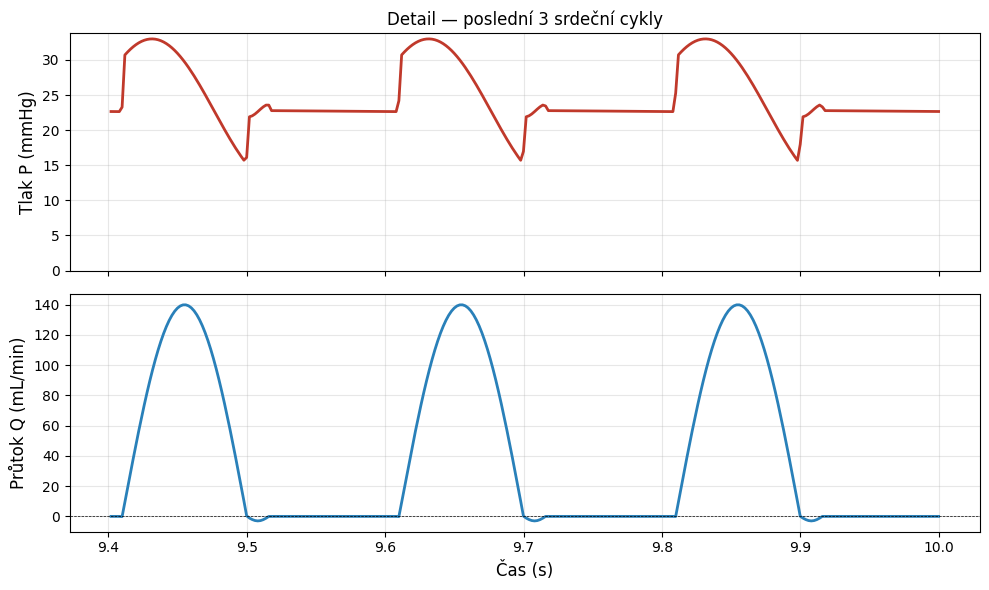

In [7]:
# ── Detail: poslední 3 srdeční cykly ─────────────────────────────────────
t_zoom_start = T_total * 60 - 3 * (T_cycle * 60)  # poslední 3 cykly v sekundách
mask_zoom = t_sec >= t_zoom_start

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1 = axes[0]
ax1.plot(t_sec[mask_zoom], P_sol[mask_zoom], color='#C0392B', linewidth=2)
ax1.set_ylabel('Tlak P (mmHg)', fontsize=12)
ax1.set_title('Detail — poslední 3 srdeční cykly', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

ax2 = axes[1]
ax2.plot(t_sec[mask_zoom], Q_full[mask_zoom], color='#2980B9', linewidth=2)
ax2.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax2.set_xlabel('Čas (s)', fontsize=12)
ax2.set_ylabel('Průtok Q (mL/min)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('windkessel_4wk_detail.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Porovnání: 3WK vs. 4WK

Pro srovnání implementujeme také 3-prvkový model (Rov. 2 z článku) — jde o speciální případ 4WK pro $L = 0$:

$$\frac{dP}{dt} + \frac{P}{R_d C} = R\frac{dQ}{dt} + \left(\frac{1}{C} + \frac{R}{R_d C}\right)Q$$

Podle citlivostní analýzy v článku (Tabulka 4) má indukčnost $L$ v normotenzní skupině zanedbatelný příspěvek (rank $\approx 0{,}01$ oproti $R_d \approx 5{,}8$). Oba modely by proto měly dávat prakticky totožné výsledky.


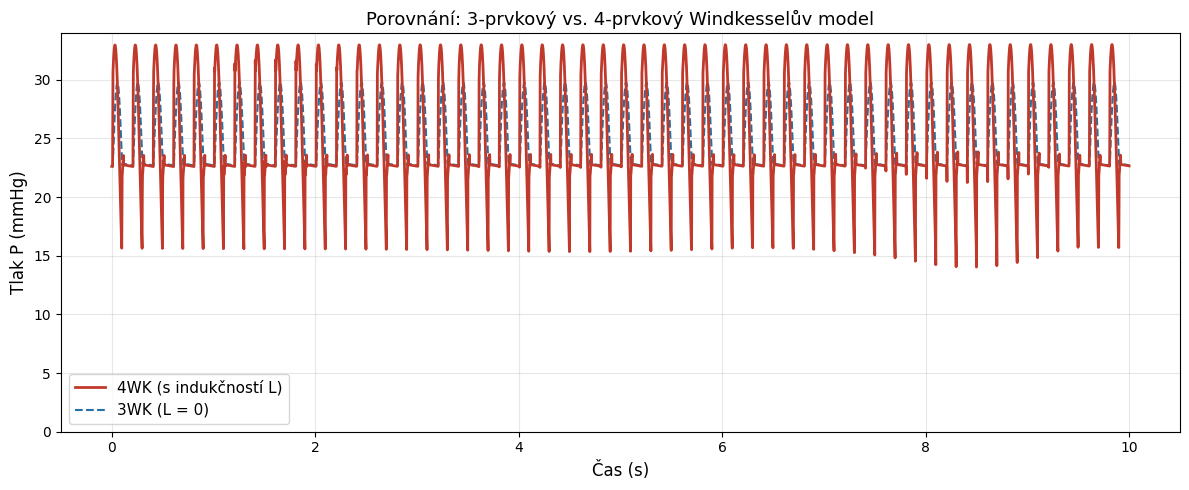

                                  3WK         4WK
--------------------------------------------------
Systolický tlak (mmHg)           29.8        33.0
Diastolický tlak (mmHg)          22.7        14.0
Střední tlak (mmHg)              24.8        24.7

Reference (Tabulka 2, skupina PL):  systolický ~33,6 mmHg,  střední ~24,1 mmHg


In [8]:
def windkessel_3wk(t, y, Rd, R, C, t_cycle, Qt_templ, QQ_templ):
    """ODE 3-prvkového Windkesselova modelu (Rov. 2) — speciální případ 4WK pro L = 0."""
    P = y[0]
    Q  = Q_func(t,  t_cycle, Qt_templ, QQ_templ)
    dQ = dQ_func(t, t_cycle, Qt_templ, QQ_templ)
    return [(-P / (Rd * C) + R * dQ + (1.0/C + R / (Rd * C)) * Q)]


# Počáteční podmínka pro 3WK (Fourierova analýza, L=0)
f_t_3wk = (R * dQ_ss + (1.0/C + R / (Rd * C)) * QQ_template)
F_k_3wk = np.fft.rfft(f_t_3wk) / N
P_k_3wk = np.array([F_k_3wk[k] / (1/(Rd*C) + 1j*k*omega) for k in range(len(F_k_3wk))])
P_ss_3wk = np.fft.irfft(P_k_3wk * N, n=N)
P0_3wk = P_ss_3wk[0]

sol_3wk = solve_ivp(
    fun=windkessel_3wk,
    t_span=t_span,
    y0=[P0_3wk],
    t_eval=t_eval,
    method='RK45', rtol=1e-8, atol=1e-10,
    args=(Rd, R, C, T_cycle, Qt_template, QQ_template)
)

# Srovnávací graf
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_sec, P_sol,        color='#C0392B', linewidth=2,   label='4WK (s indukčností L)', zorder=3)
ax.plot(t_sec, sol_3wk.y[0], color='#2471A3', linewidth=1.5, label='3WK (L = 0)',
        linestyle='--', zorder=2)
ax.set_xlabel('Čas (s)', fontsize=12)
ax.set_ylabel('Tlak P (mmHg)', fontsize=12)
ax.set_title('Porovnání: 3-prvkový vs. 4-prvkový Windkesselův model', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('windkessel_3vs4_porovnani.png', dpi=150, bbox_inches='tight')
plt.show()

# Numerické srovnání
P3 = sol_3wk.y[0]
print(f"{'':26s} {'3WK':>10s}  {'4WK':>10s}")
print("-" * 50)
print(f"{'Systolický tlak (mmHg)':26s} {np.max(P3):>10.1f}  {np.max(P_sol):>10.1f}")
print(f"{'Diastolický tlak (mmHg)':26s} {np.min(P3):>10.1f}  {np.min(P_sol):>10.1f}")
print(f"{'Střední tlak (mmHg)':26s} {np.mean(P3):>10.1f}  {np.mean(P_sol):>10.1f}")
print()
print("Reference (Tabulka 2, skupina PL):  systolický ~33,6 mmHg,  střední ~24,1 mmHg")


## 6. Shrnutí

Simulace reprodukuje průběh arteriálního tlaku v plicní tepně popsaný v práci Gerringer et al. (2018):

| Veličina | Simulace | Článek (PL) |
|----------|----------|-------------|
| Systolický tlak | 33,0 mmHg | 33,6 ± 4,9 mmHg |
| Střední tlak (mPAP) | 24,7 mmHg | 24,1 ± 4,9 mmHg |
| Diastolický tlak | 14,1 mmHg | ~15–18 mmHg (Obr. 1B) |
| Pulzní tlak | 18,9 mmHg | ~18 mmHg (Obr. 1B) |

Střední tlak se od referenční hodnoty liší o méně než 3 %, systolický o 2 %. Diastolický tlak a pulzní tlak odpovídají průběhům z Obr. 1B článku.

Počáteční podmínka pro simulaci je stanovena analyticky Fourierovou analýzou ustáleného stavu, čímž je zajištěno, že zobrazovaných 10 sekund odpovídá plně ustálenému periodickému ději.

Porovnání 3WK a 4WK modelů potvrzuje závěr článku: indukčnost $L$ přispívá k výsledku zanedbatelně — oba modely dávají prakticky totožné hodnoty, což odpovídá citlivostní analýze (rank $L \approx 0{,}01$, Tabulka 4).

**Použité parametry:** $R_d = 0{,}57$, $R = 0{,}05$, $C = 0{,}44$, $L = 2{,}6 \times 10^{-5}$ (vše v jednotkách mmHg·min·mL, normotenzní skupina PL, Tabulka 2).
